In [1]:
from ml_enhance import QuantumFPDatasetBuilder, RDKitFeatureCalculator, get_preprocessed_smiles
from pathlib import Path
from rdkit import Chem
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DATA_SOURCE = Path("../data/AqSolDB/data_curated.csv")
# raw_data = pd.read_csv(DATA_SOURCE)
# QFP_preprocessed_smiles = np.array([get_preprocessed_smiles(smiles) for smiles in raw_data["SMILES"]])
# Write the smiles to JSON
# Run data through QuantumFP

# QFP_OUTPUT_PATH = Path("../data/QuantumFP/QFP_output")
# builder = QuantumFPDatasetBuilder(QFP_OUTPUT_PATH)
# df, errors = builder.build_dataset(multiprocess=True)

# rdkit_calculator = RDKitFeatureCalculator()
# df = rdkit_calculator.add_to_dataframe(df, multiprocess=True)

# Add solutbility:
# build_solubility_lookup
# attach_solubility

In [3]:
df = pd.read_csv('../data/processed_dataset.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8837 entries, 0 to 8836
Columns: 279 entries, smiles to canon_smiles
dtypes: float64(167), int64(110), str(2)
memory usage: 18.8 MB


In [5]:
df.head()

,smiles,energy,atomization_energy,homo_lumo_gap,ionization_energy,electron_affinity,chemical_potential,molecular_dipole_norm,molecular_quadrupole_principal_invariant_2,molecular_quadrupole_principal_invariant_3,...,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,solubility,canon_smiles
0,[O:1]=[C:2]1[N:3]([H:14])[c:4]2[c:5]([H:15])[c...,-34.129003,5.239994,0.089513,0.476438,0.201907,-0.338539,1.513984,-191.687655,-37.755113,...,0,0,0,0,0,0,0,0,-3.254767,O=C1Nc2cccc3cccc1c23
1,[Cl:1][c:2]1[c:3]([H:10])[c:4]([H:11])[c:5]([C...,-26.123298,3.330826,0.105979,0.507545,0.200001,-0.356143,0.965182,-188.636399,720.869344,...,0,0,0,0,0,0,0,0,-2.177078,O=Cc1ccc(Cl)cc1
2,[C:1]([C:2]([C:3]([H:19])([H:20])[H:21])([C:4]...,-45.121773,7.140100,0.154440,0.463887,0.109782,-0.296101,0.909688,-169.958738,291.625442,...,0,0,0,0,0,0,0,0,-3.430239,CC(C)(C)c1ccc(OCC2CO2)cc1
3,[C:1]([c:2]1[c:3]([H:17])[c:4]([H:18])[c:5]([H...,-39.453112,5.850939,0.073945,0.299042,0.004866,-0.145684,5.103982,-1306.769545,16565.487506,...,0,0,0,0,0,0,0,0,-2.256645,Cc1cccc(C)c1OCC(=O)O
4,[C:1]([O:2][C:3](=[O:4])[c:5]1[c:6]([H:28])[c:...,-72.427791,8.519924,0.068689,0.479849,0.249515,-0.373551,2.145071,-670.362641,-1839.250752,...,0,0,0,0,0,0,0,0,-5.965155,COC(=O)c1ccc(C(=O)Nc2cc(Cl)ccc2Cl)cc1[N+](=O)[O-]


In [6]:
# def canonicalize_smiles(smiles: str) -> str | None:
#     if not isinstance(smiles, str):
#         return None

#     mol = Chem.MolFromSmiles(smiles)
#     if mol is None:
#         return None

#     for atom in mol.GetAtoms():
#         atom.SetAtomMapNum(0)

#     return Chem.MolToSmiles(mol, canonical=True)

# def build_solubility_lookup(raw_df: pd.DataFrame) -> pd.Series:
#     """
#     Returns a Series indexed by canonical SMILES containing solubility.
#     """
#     df = raw_df[["SMILES", "Solubility"]].copy()

#     df["canon_smiles"] = df["SMILES"].apply(canonicalize_smiles)
#     df = df.dropna(subset=["canon_smiles"])

#     return df.set_index("canon_smiles")["Solubility"]

# def attach_solubility(feature_df: pd.DataFrame, sol_lookup: pd.Series) -> pd.DataFrame:
#     df = feature_df.copy()

#     df["canon_smiles"] = df["smiles"].apply(canonicalize_smiles)
#     df["solubility"] = df["canon_smiles"].map(sol_lookup)

#     return df

In [7]:
df.isna().sum().to_numpy()

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0, 72, 72, 72, 72,  0,  0,  0, 73, 73, 73, 73, 73, 73, 73,
       73,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0

In [8]:
df.isna().sum()[df.isna().sum() > 0]

MaxPartialCharge       72
MinPartialCharge       72
MaxAbsPartialCharge    72
MinAbsPartialCharge    72
BCUT2D_MWHI            73
BCUT2D_MWLOW           73
BCUT2D_CHGHI           73
BCUT2D_CHGLO           73
BCUT2D_LOGPHI          73
BCUT2D_LOGPLOW         73
BCUT2D_MRHI            73
BCUT2D_MRLOW           73
dtype: int64

In [9]:
nans = df[df.isna().any(axis=1)]
nans["canon_smiles"].to_numpy()

array(['CCCCCCC[CH2][Sn]([Cl])([Cl])[Cl]',
       'CCCCC(CC)C(=O)[O][Co][O]B([O][Co])[O][Co]([O]C(=O)C(CC)CCCC)[O]C(=O)C(CC)CCCC',
       'CCCCCCC[CH2][Sn](=[O])[CH2]CCCCCCC', '[O]=[Ca]',
       '[O]=[V](=[O])[O][V](=[O])=[O]',
       'C[CH2][Pb]([CH2]C)([CH2]C)[CH2]C',
       'CCCCC(CC)COC(=O)C[S][Sn]([CH3])([CH3])[S]CC(=O)OCC(CC)CCCC',
       'O=[N+]([O-])[O][Bi]([O][N+](=O)[O-])[O][N+](=O)[O-]',
       '[O]=[Mo](=[O])([OH])[OH]', 'C=C(C)C(=O)[O][Zn][OH]', 'B#N',
       'CCC[CH2][Sn]([CH2]CCC)([CH2]CCC)[CH2]CCC', '[S]=[Sr]', 'O=[Se]=O',
       'CCC[CH2][Sn]([CH2]CCC)([CH2]CCC)[O][Sn]([CH2]CCC)([CH2]CCC)[CH2]CCC',
       '[O]=[Pb]', '[O]=[Mo](=[O])=[O]', '[S]=[Fe]', '[O]=[Ni]',
       '[O]=[Mn]', '[O]=[Cu]',
       'CCCCCCCCCCCC[S][Sn]([CH2]CCC)([CH2]CCC)[S]CCCCCCCCCCCC',
       '[O]=[Mn]=[O]', 'CCCCCCC[CH2][Sn]1([CH2]CCCCCCC)[O]C(=O)C[S]1',
       'CCCCCCC[CH2][Sn]([CH2]CCCCCCC)([CH2]CCCCCCC)[CH2]CCCCCCC',
       'Clc1c(Cl)c(Br)c2c(c1Cl)C1=Nc3c4c(Cl)c(Br)c(Cl)c(Br)c4c4[n]3[Cu][n]3c(c

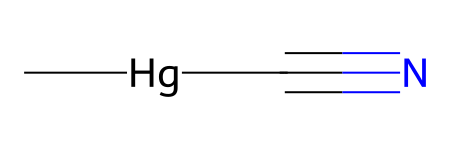

In [10]:
Chem.MolFromSmiles('[CH3][Hg][C]#N')

In [11]:
features_df = df.drop(["smiles", "canon_smiles"], axis=1)

ValueError: supplied range of [-0.2741388281085758, inf] is not finite

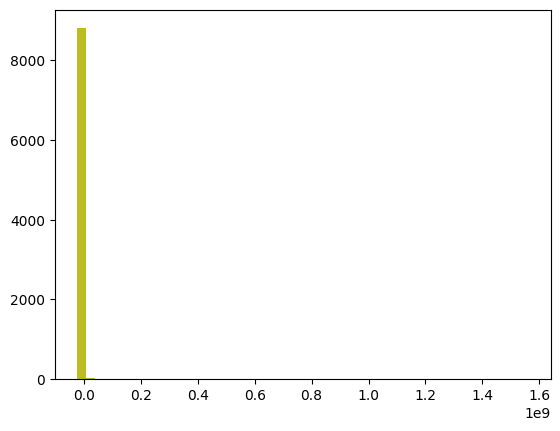

In [12]:
subset_cols = features_df.columns

for feature in subset_cols:
    plt.hist(features_df[feature], bins=50)

plt.tight_layout()
plt.grid(False)
plt.show()

In [13]:
from collections import Counter

df_clean = df.dropna()

print()

total_atom_types = []
count = 0
for smiles in df_clean["canon_smiles"]:
    mol = Chem.MolFromSmiles(smiles)

    mol_atom_types = [atom.GetSymbol() for atom in mol.GetAtoms()]

    total_atom_types.extend(mol_atom_types)

print(Counter(total_atom_types))


Counter({'C': 104255, 'O': 21909, 'N': 10451, 'Cl': 3715, 'S': 1853, 'F': 1204, 'Br': 468, 'P': 332, 'I': 133, 'Si': 93, 'B': 7, 'Al': 1, 'H': 1})


In [14]:
Counter({'C': 104752, 'O': 22047, 'N': 10486, 'Cl': 3754, 'S': 1874, 'F': 1204, 'Br': 474, 'P': 332, 'I': 133, 'Si': 93, 'Sn': 18, 'Se': 10, 'B': 9, 'Pb': 6, 'Co': 5, 'Zn': 4, 'Cu': 4, 'As': 4, 'V': 3, 'Mo': 3, 'Cd': 3, 'Mn': 2, 'W': 2, 'Nb': 2, 'Cr': 2, 'Te': 2, 'Sb': 2, 'Ge': 2, 'Ca': 1, 'Bi': 1, 'Al': 1, 'Sr': 1, 'H': 1, 'Fe': 1, 'Ni': 1, 'Ti': 1, 'Zr': 1, 'Be': 1, 'Ce': 1, 'Hg': 1, 'Y': 1})

Counter({'C': 104752,
         'O': 22047,
         'N': 10486,
         'Cl': 3754,
         'S': 1874,
         'F': 1204,
         'Br': 474,
         'P': 332,
         'I': 133,
         'Si': 93,
         'Sn': 18,
         'Se': 10,
         'B': 9,
         'Pb': 6,
         'Co': 5,
         'Zn': 4,
         'Cu': 4,
         'As': 4,
         'V': 3,
         'Mo': 3,
         'Cd': 3,
         'Mn': 2,
         'W': 2,
         'Nb': 2,
         'Cr': 2,
         'Te': 2,
         'Sb': 2,
         'Ge': 2,
         'Ca': 1,
         'Bi': 1,
         'Al': 1,
         'Sr': 1,
         'H': 1,
         'Fe': 1,
         'Ni': 1,
         'Ti': 1,
         'Zr': 1,
         'Be': 1,
         'Ce': 1,
         'Hg': 1,
         'Y': 1})

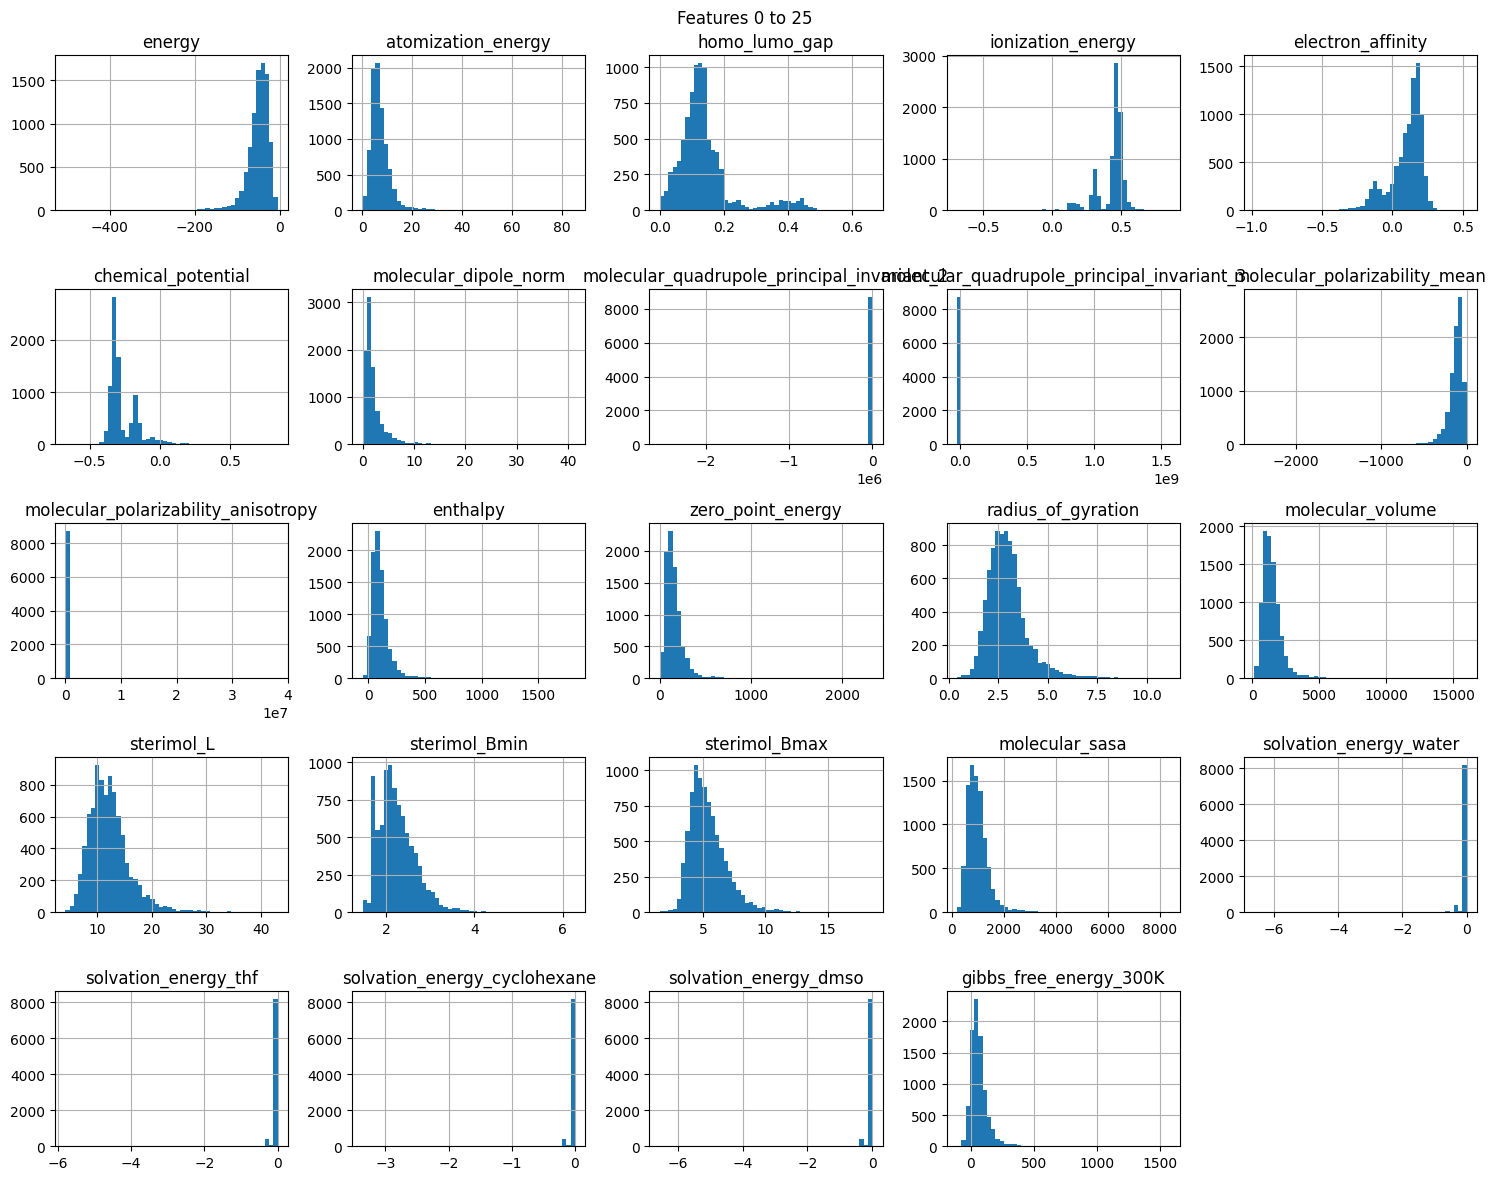

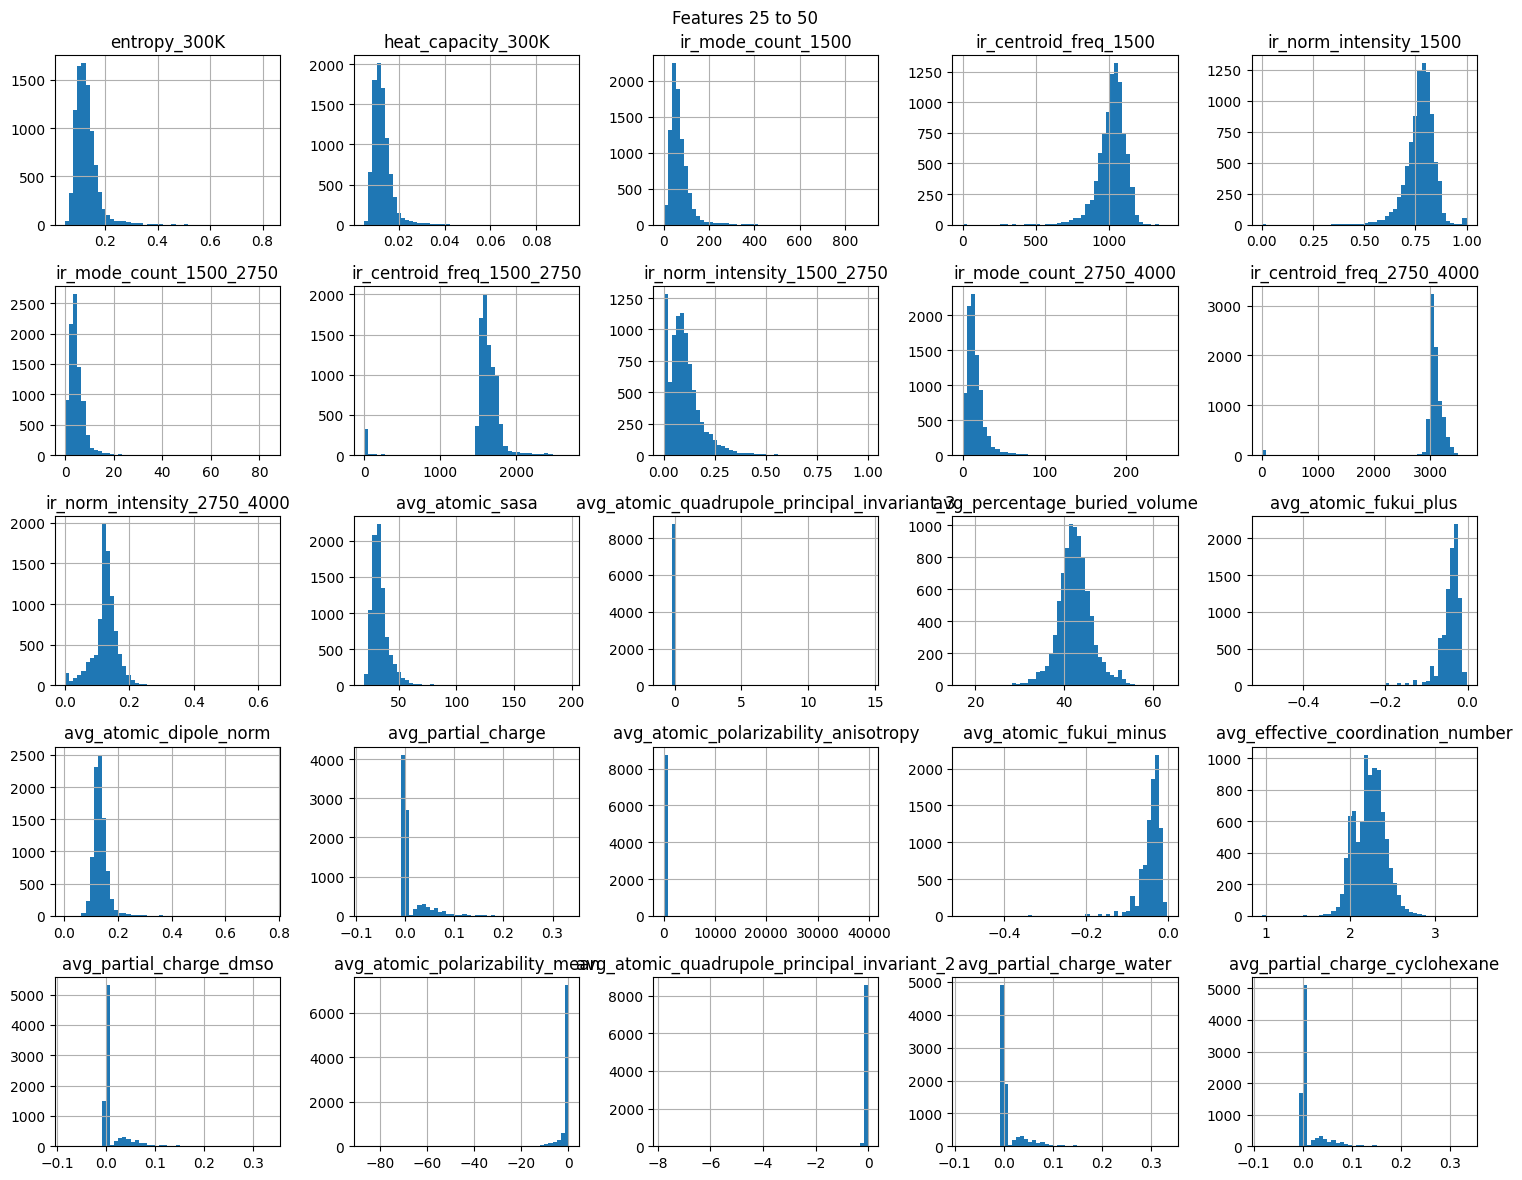

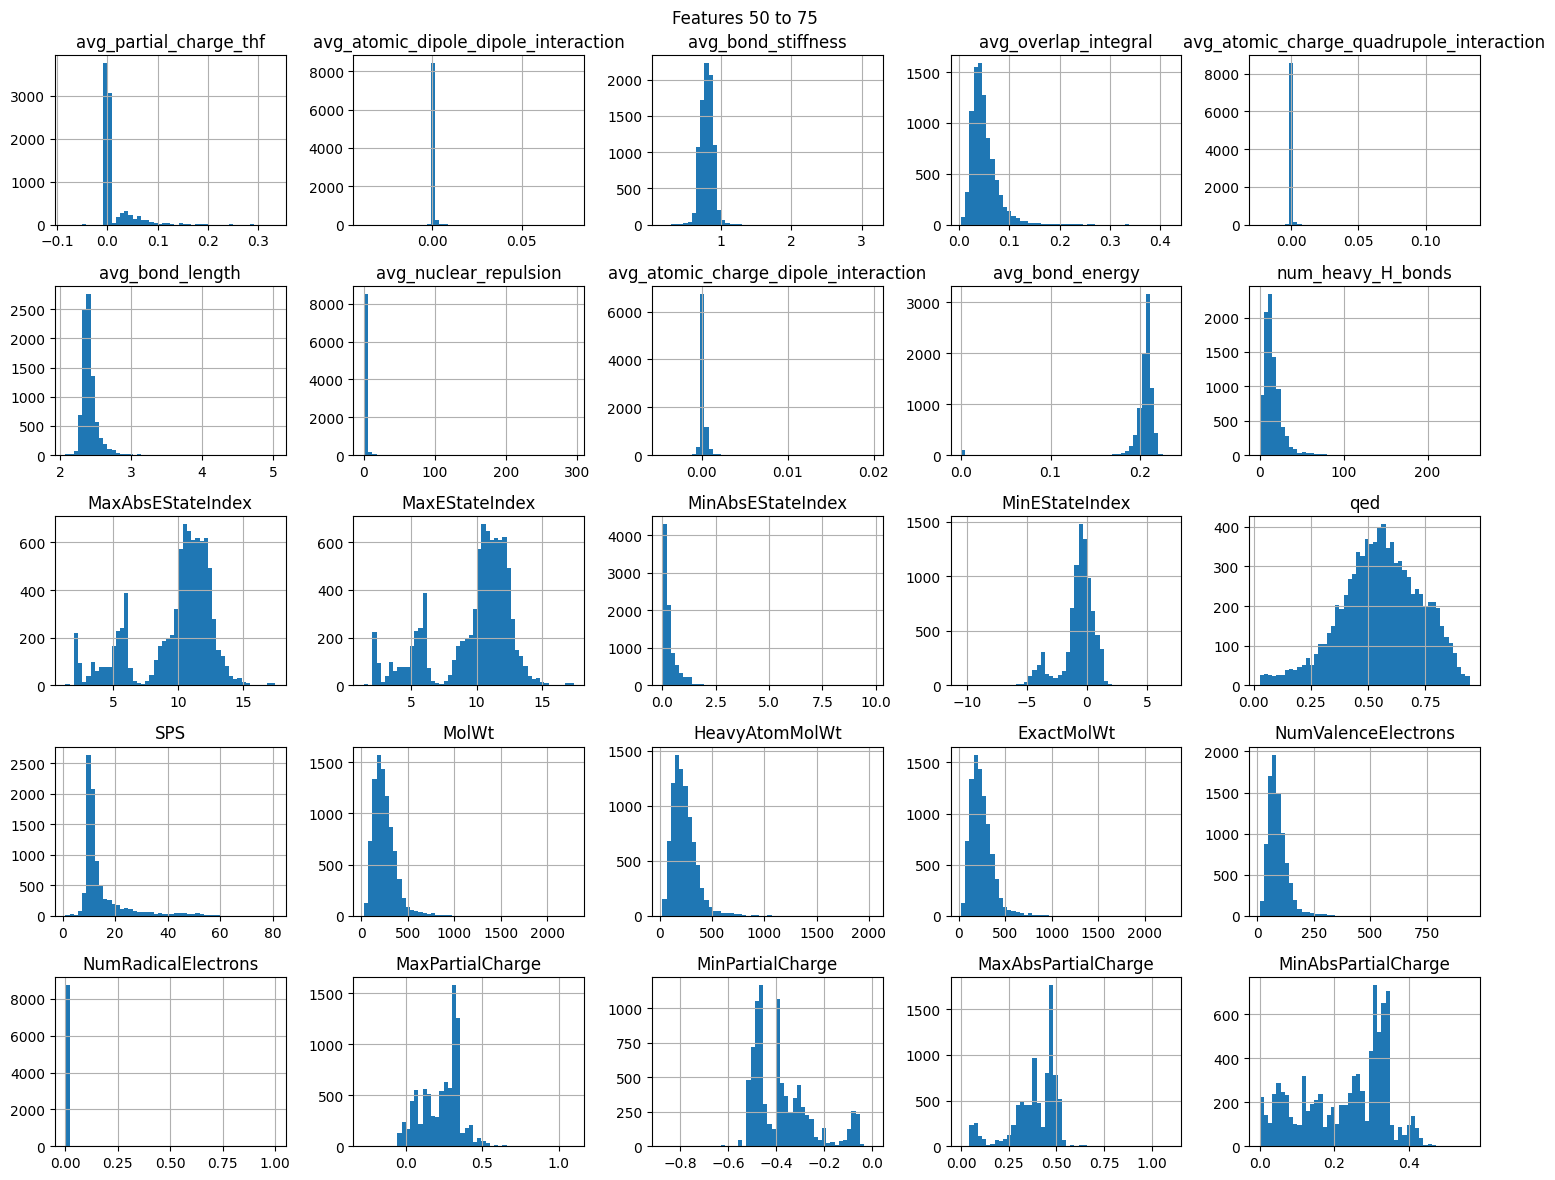

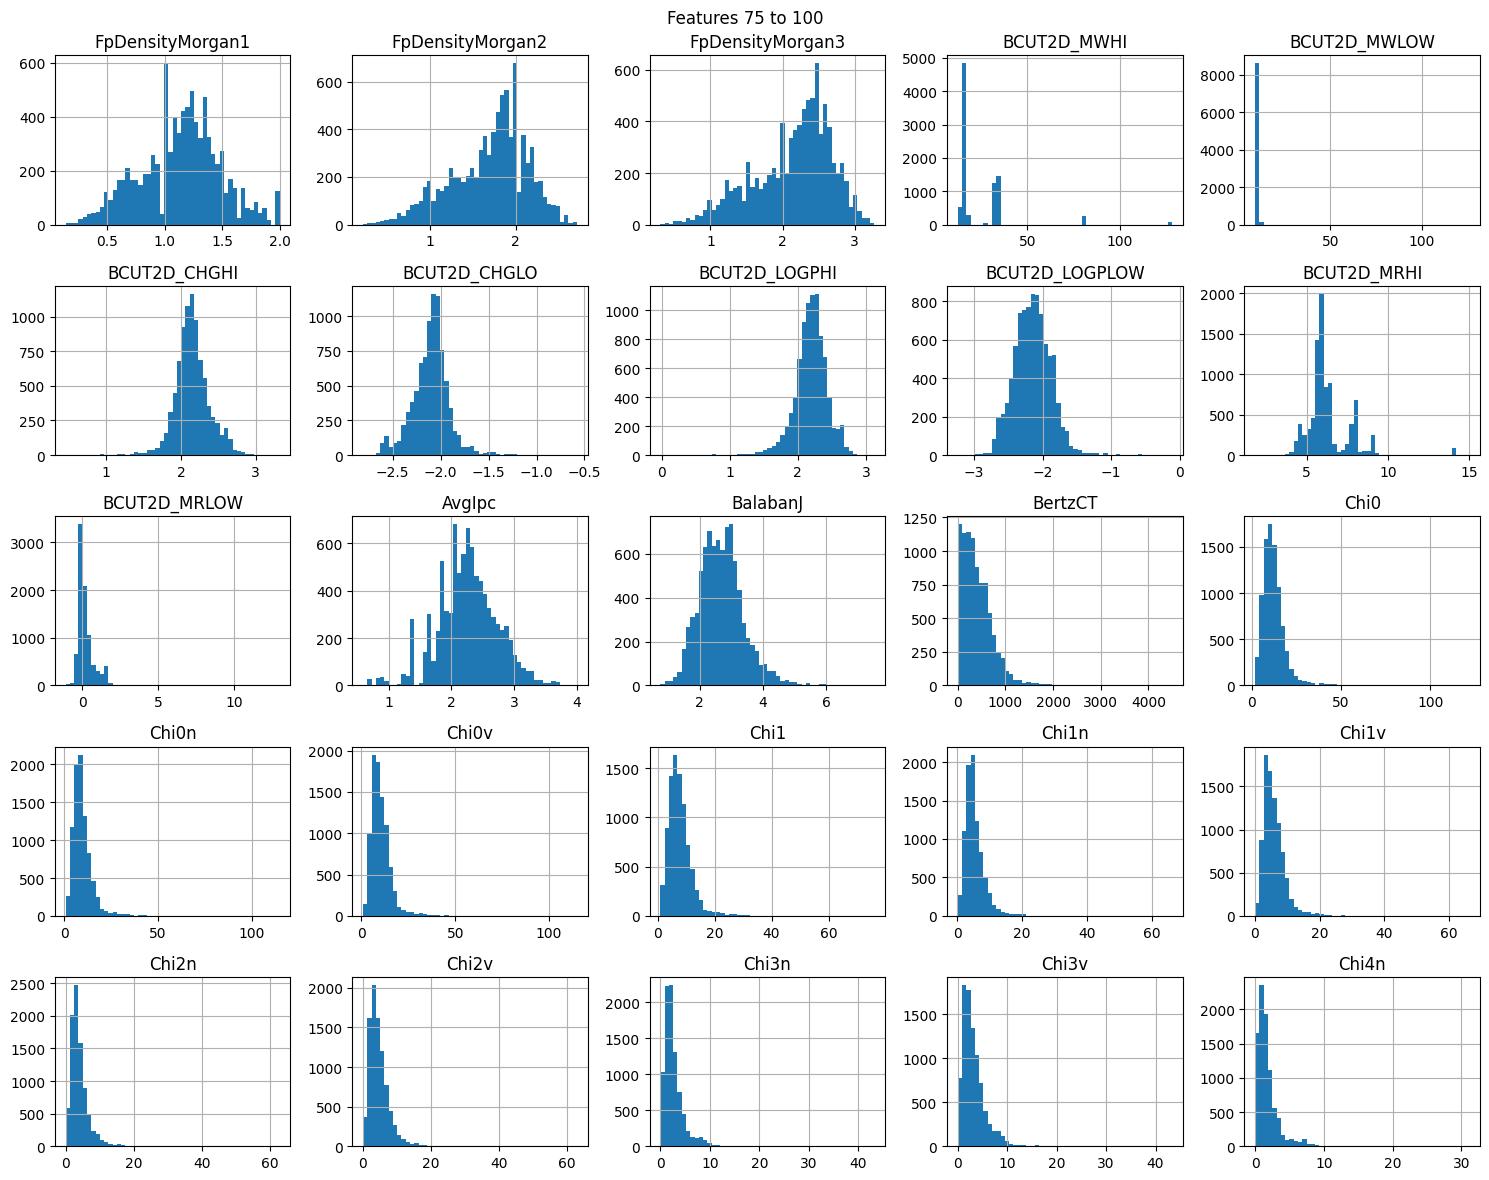

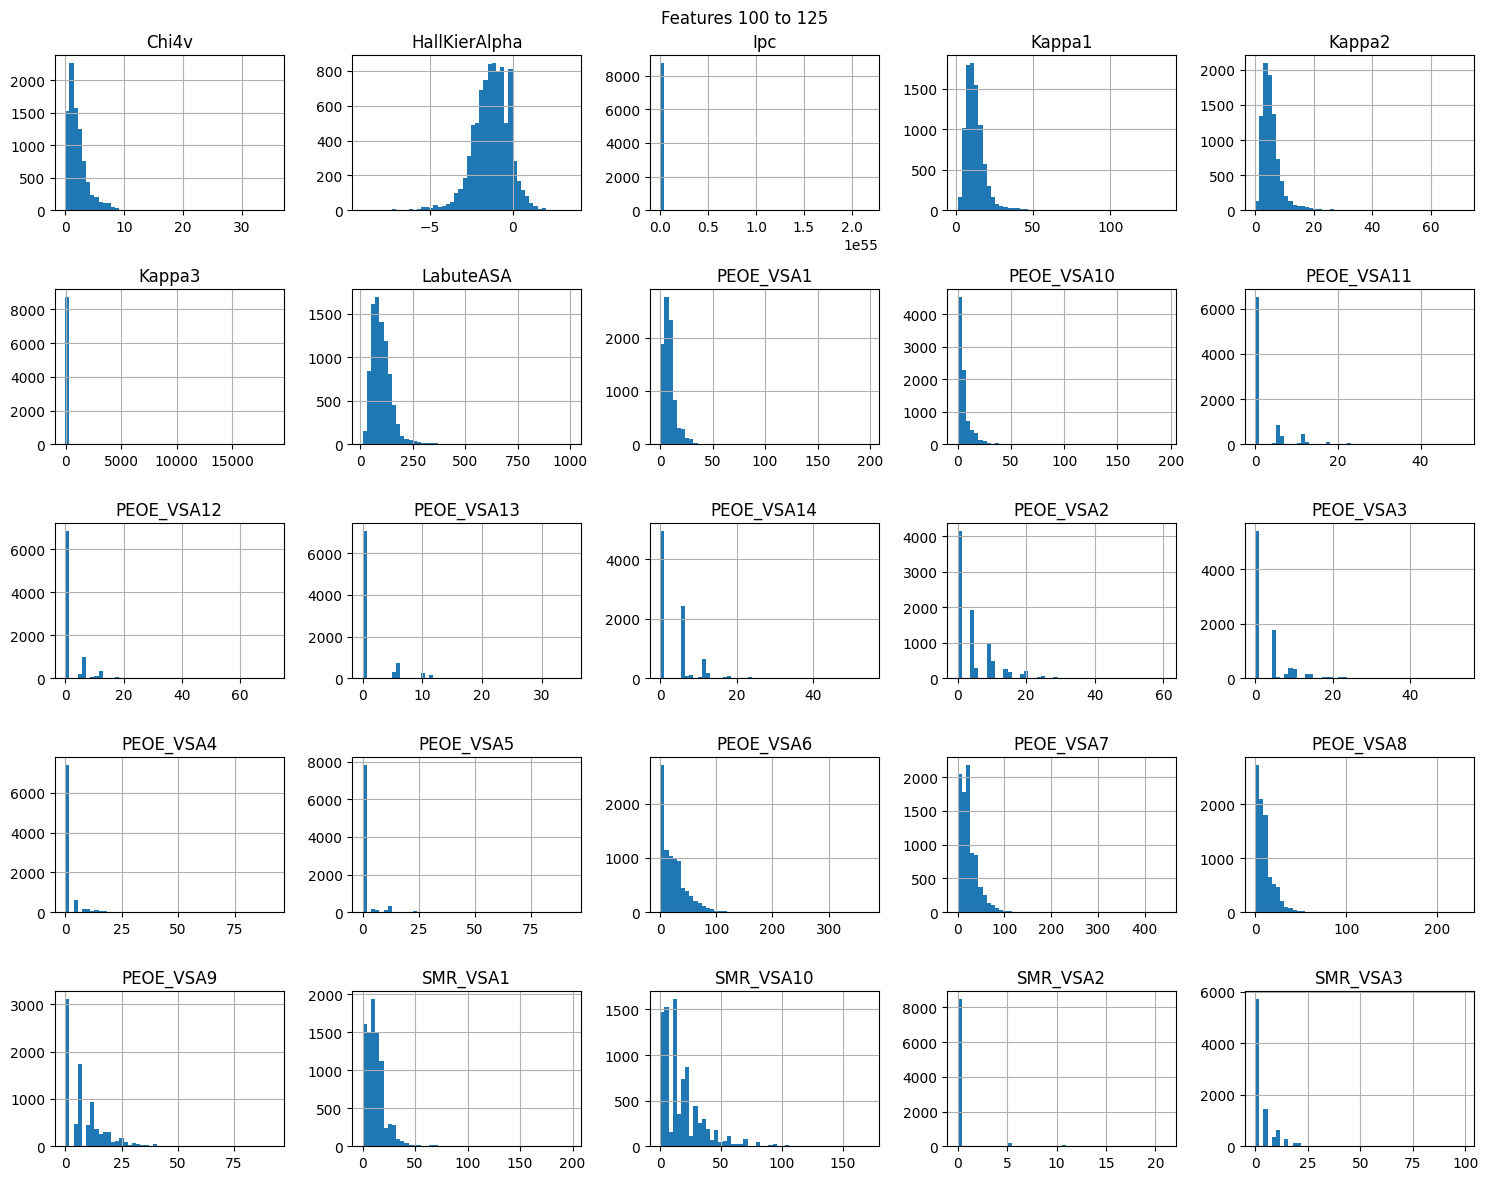

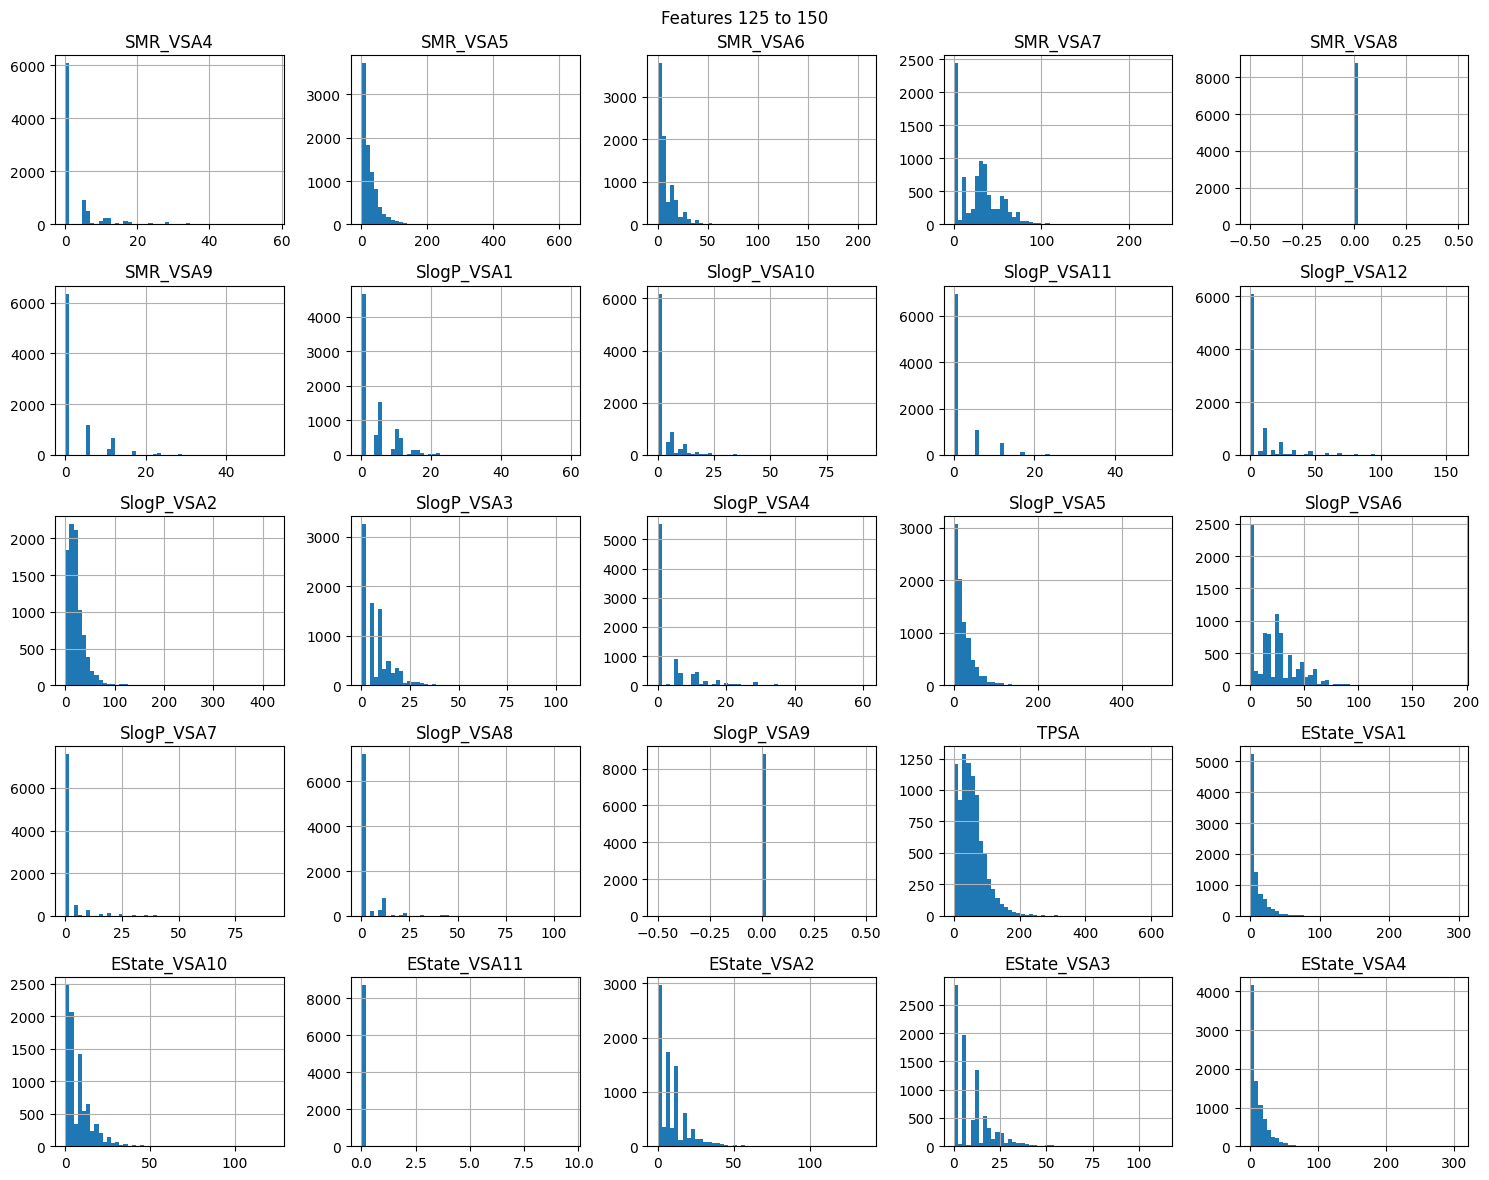

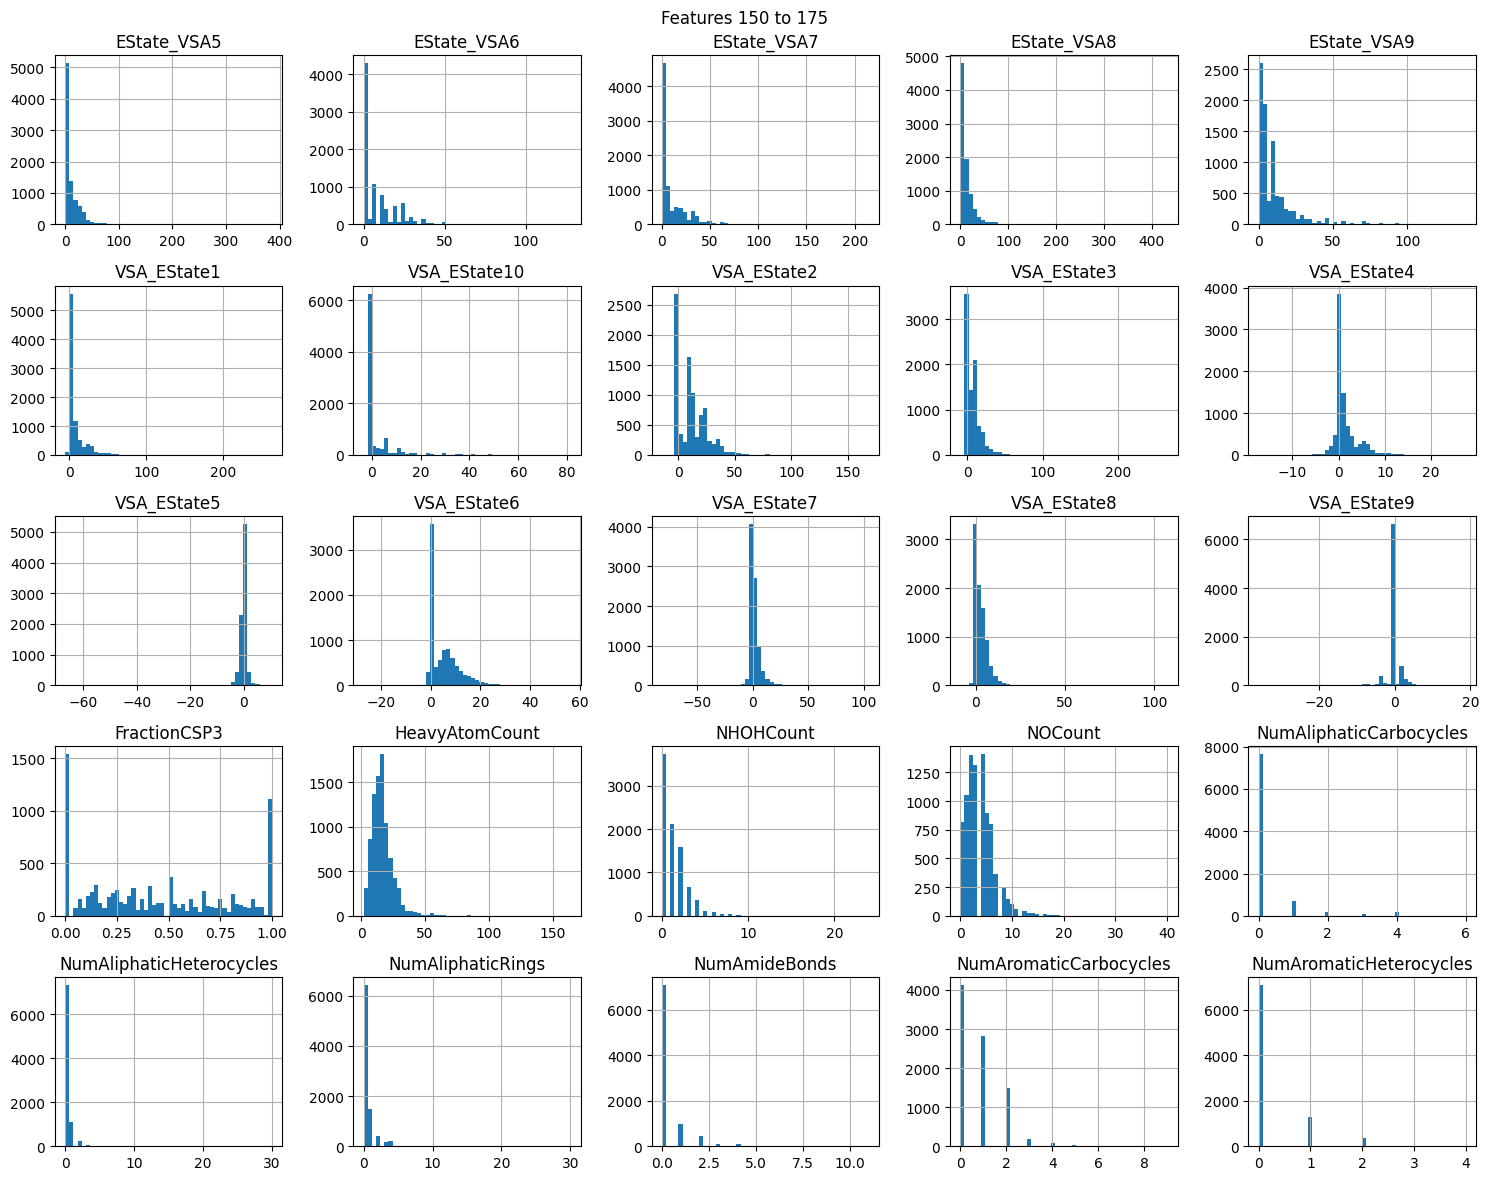

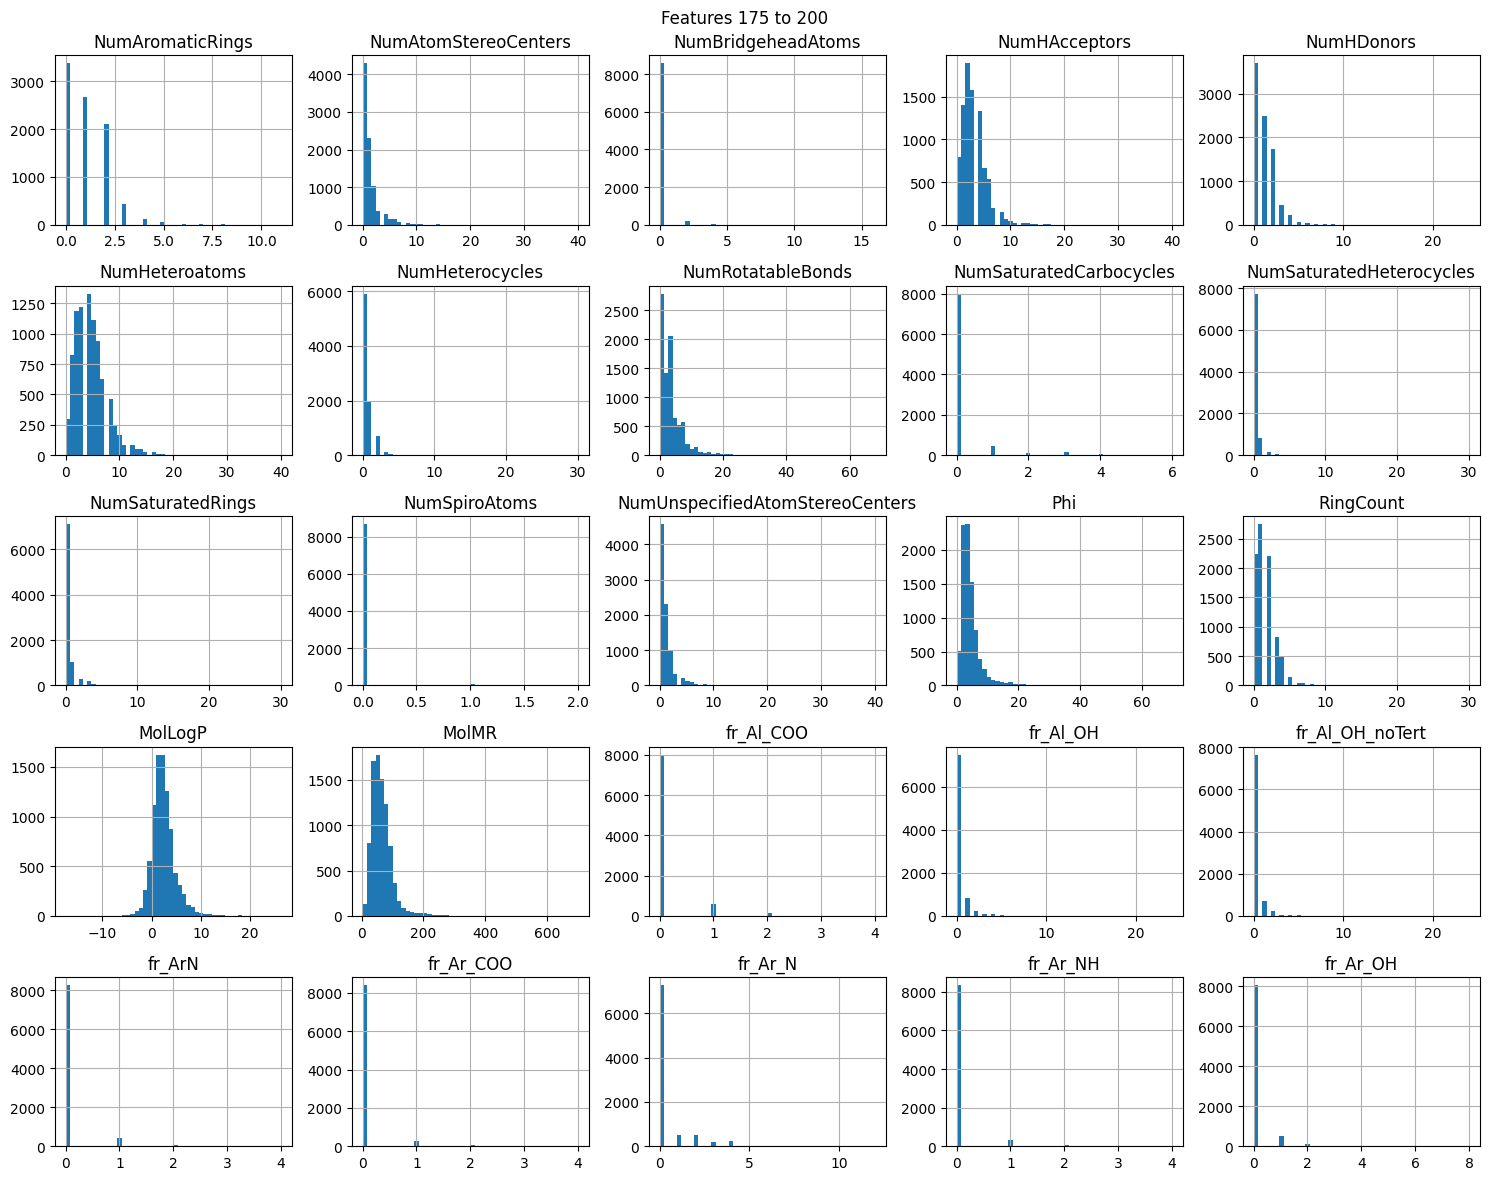

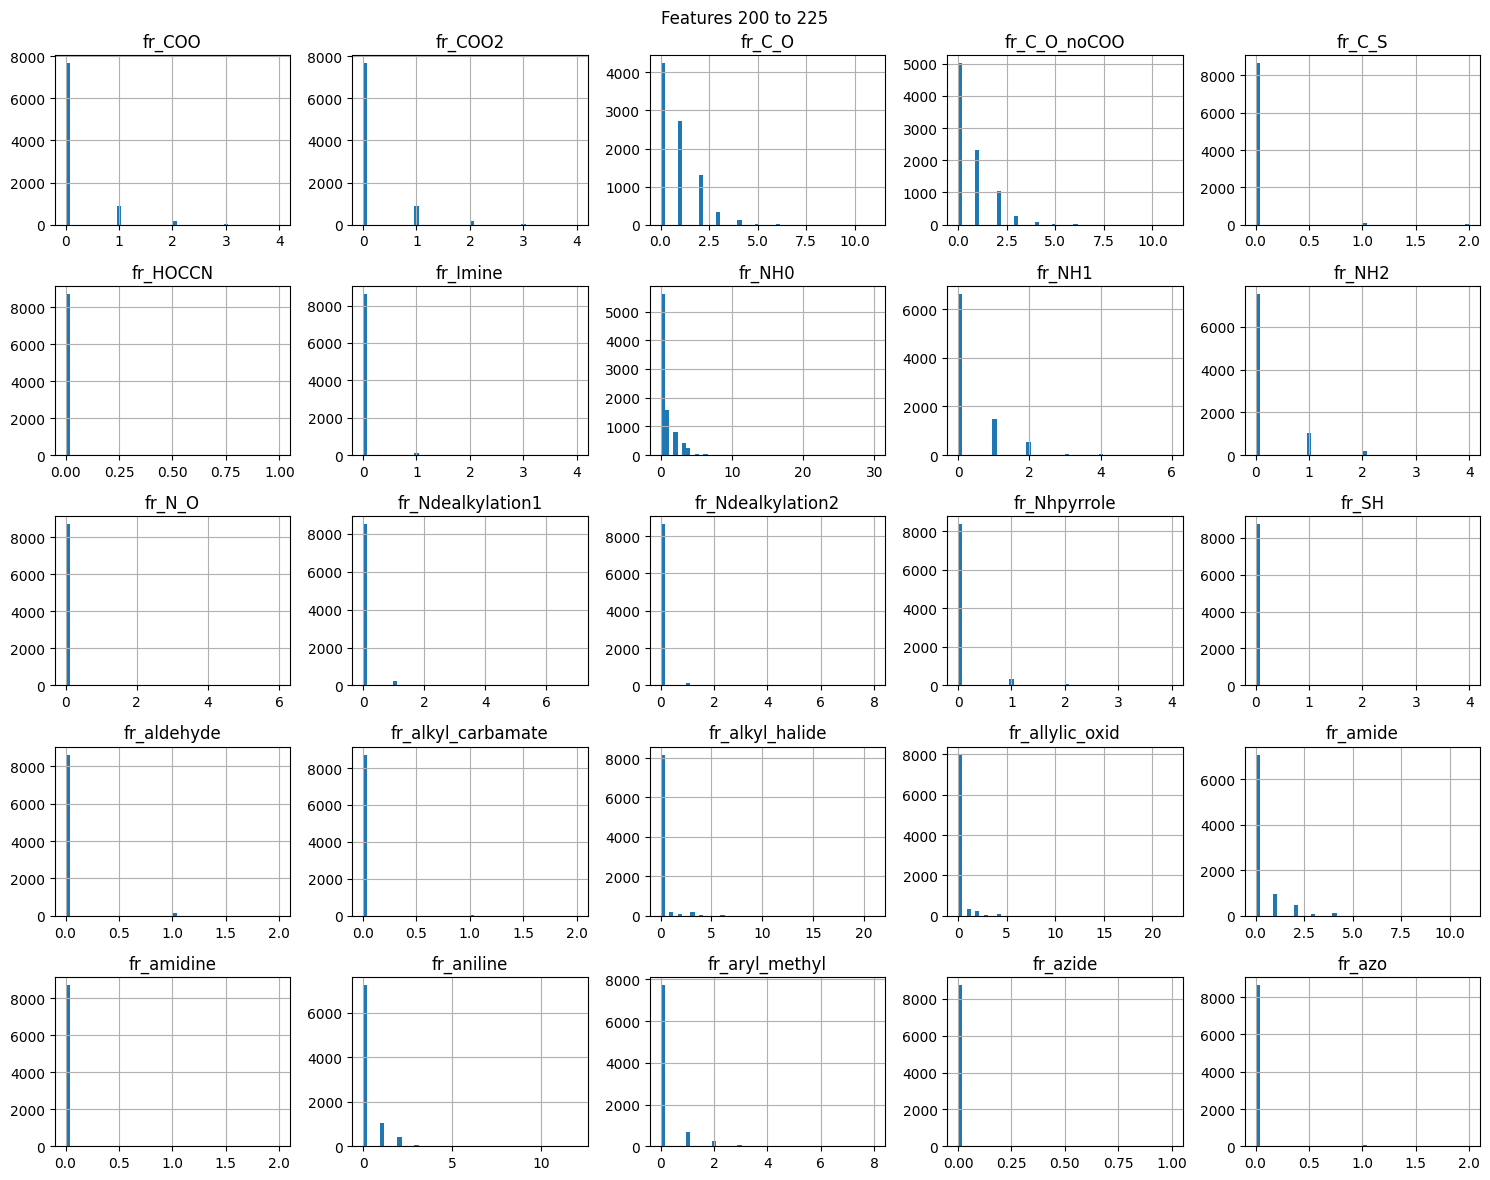

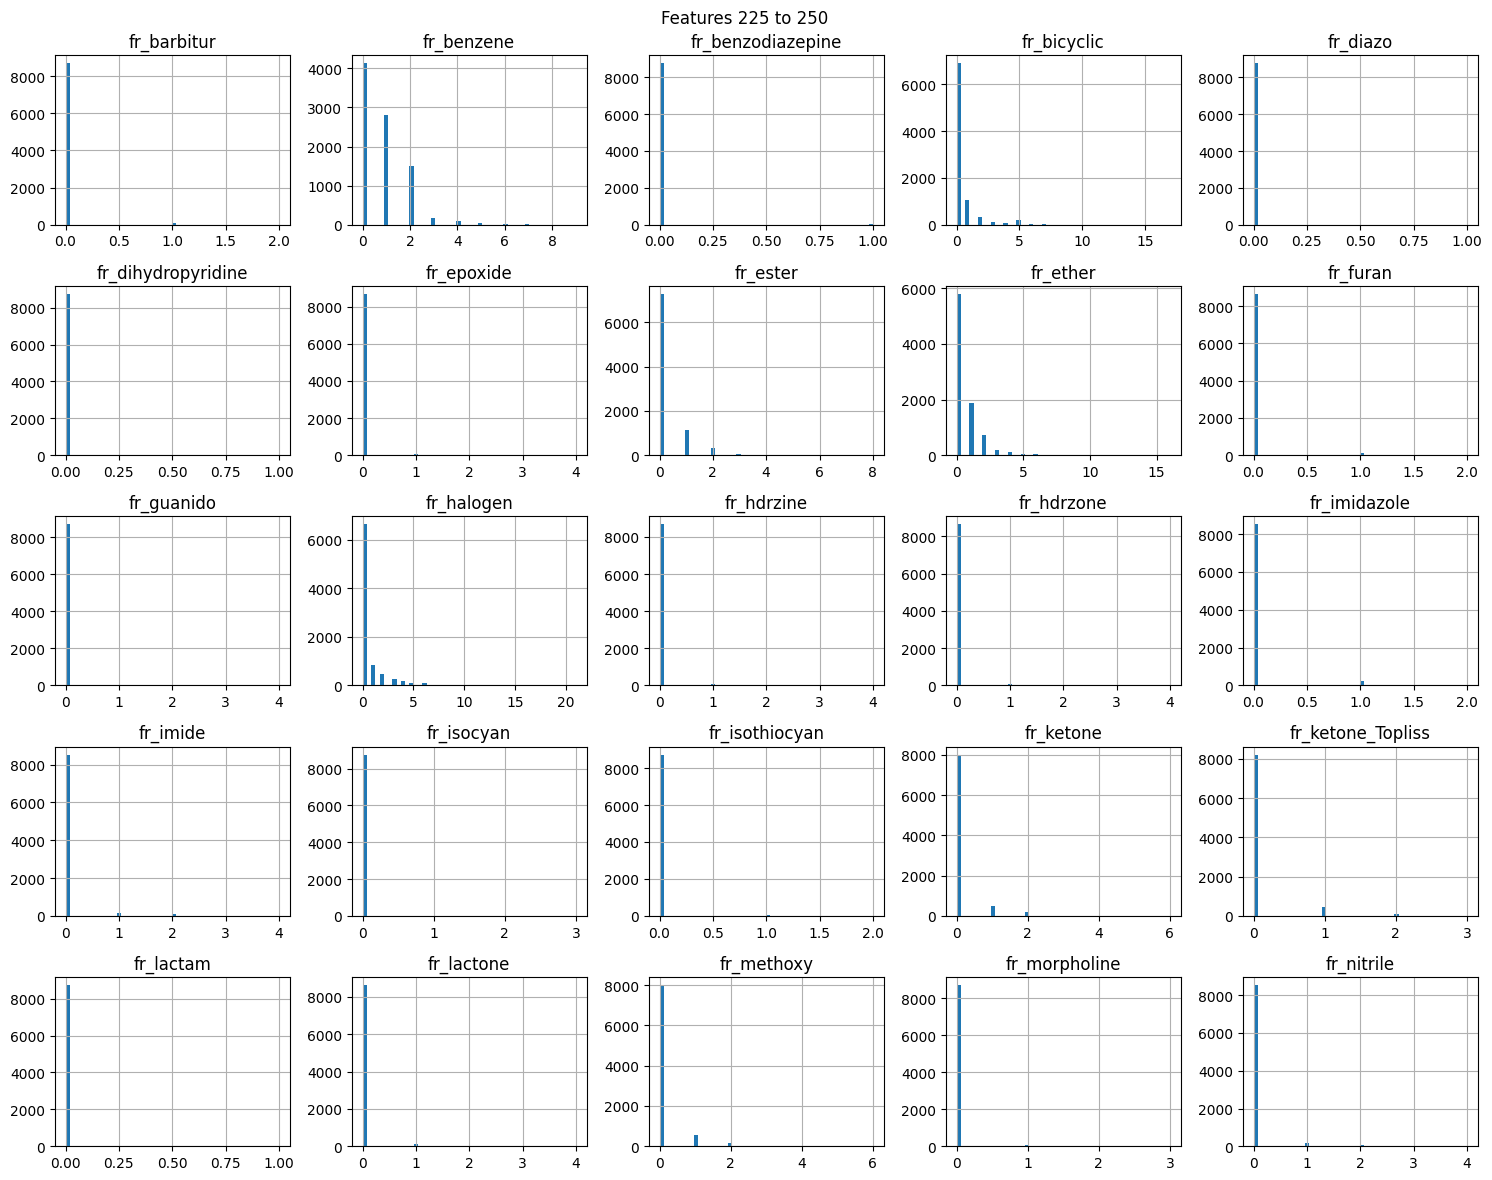

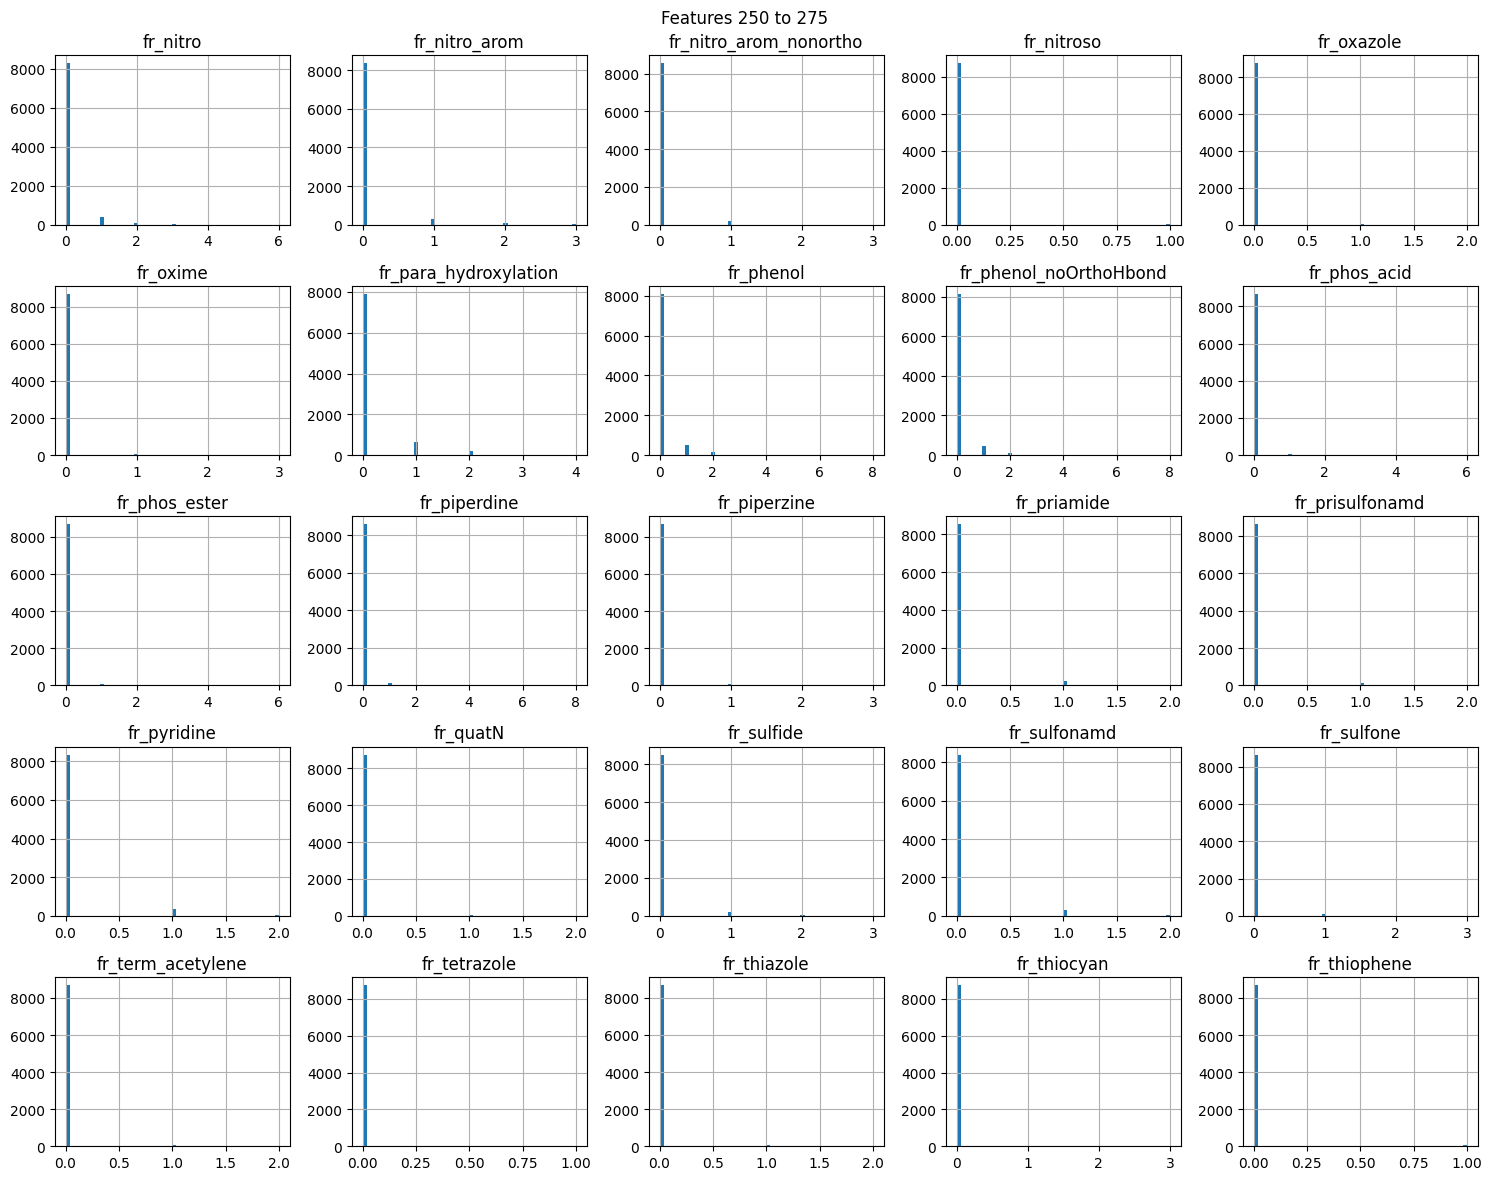

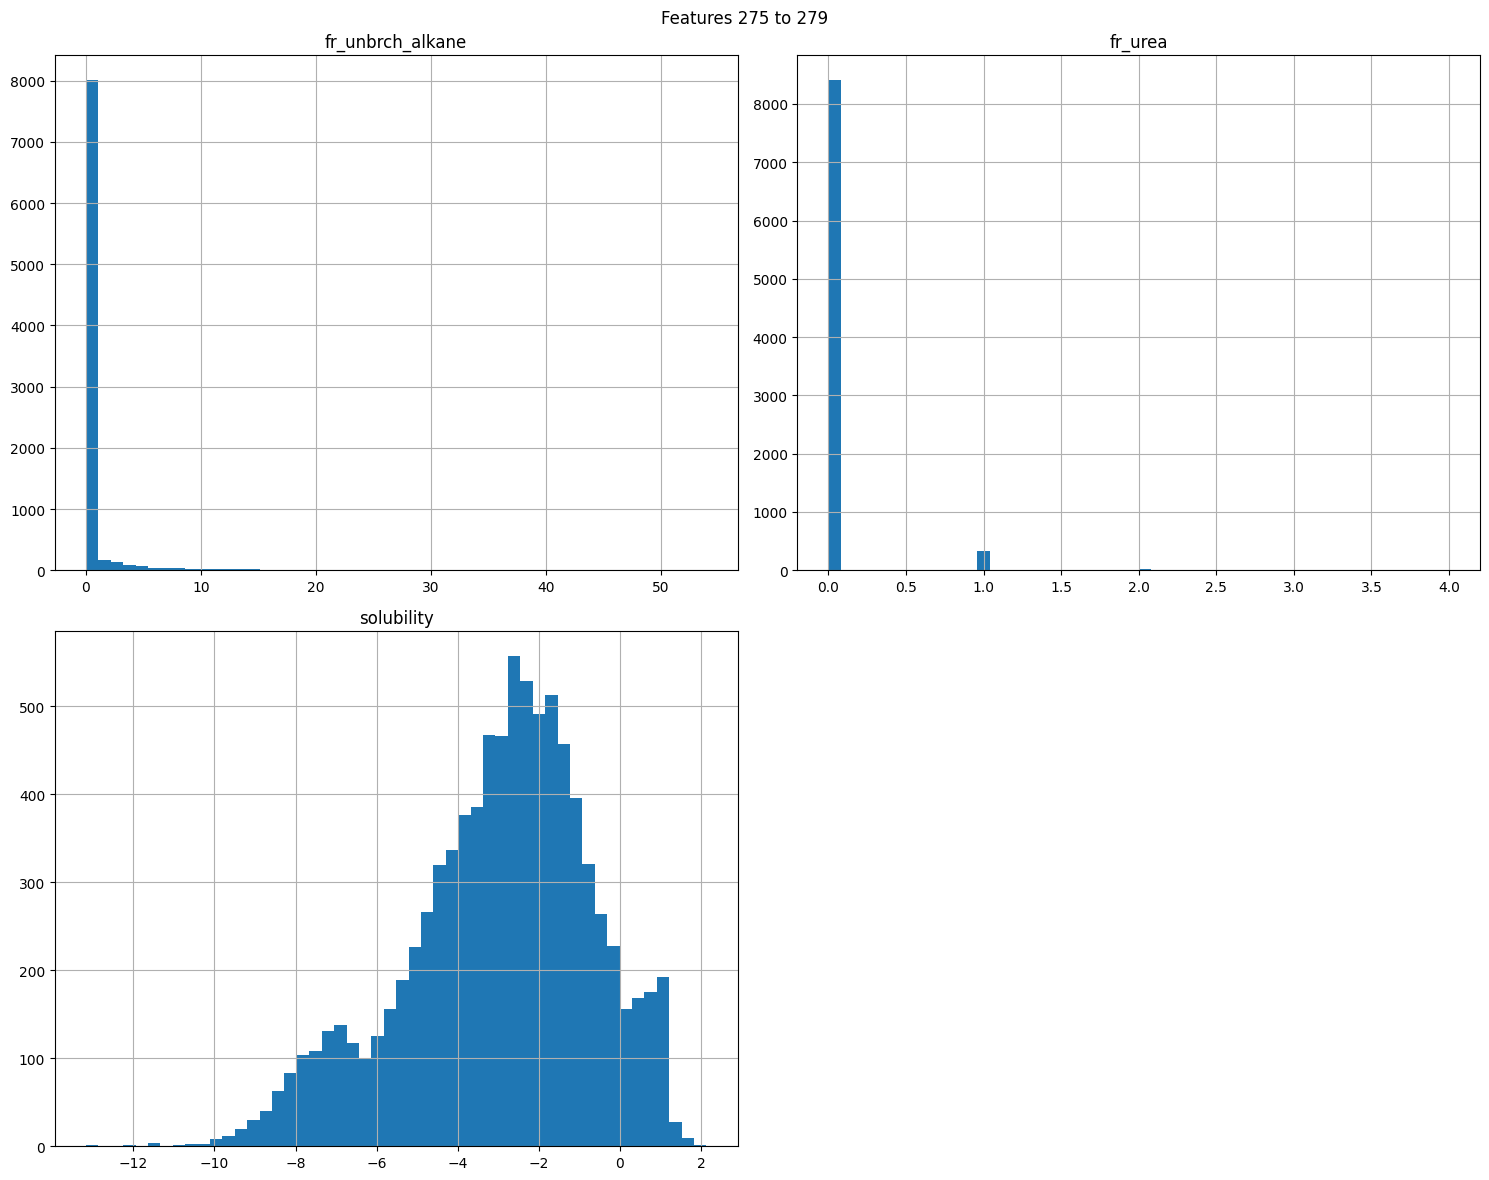

In [15]:
cols = df_clean.columns
batch_size = 25

for i in range(0, len(cols), batch_size):
    try:
        batch = cols[i:i+batch_size]
        df_clean[batch].hist(bins=50, figsize=(15, 12))
        plt.suptitle(f"Features {i} to {i+len(batch)}")
        plt.tight_layout()
        plt.show()
    except:
        print(batch)

In [19]:
df_clean.to_csv("../data/processed_dataset_wo_metals.csv", index=False)

In [18]:
df_clean.columns

Index(['smiles', 'energy', 'atomization_energy', 'homo_lumo_gap',
       'ionization_energy', 'electron_affinity', 'chemical_potential',
       'molecular_dipole_norm', 'molecular_quadrupole_principal_invariant_2',
       'molecular_quadrupole_principal_invariant_3',
       ...
       'fr_sulfone', 'fr_term_acetylene', 'fr_tetrazole', 'fr_thiazole',
       'fr_thiocyan', 'fr_thiophene', 'fr_unbrch_alkane', 'fr_urea',
       'solubility', 'canon_smiles'],
      dtype='str', length=279)